Data ingelezen: 96 tijdstappen (24 uur, dt = 0.25 h)
Prijs range: 0.0023 .. 0.0592 EUR/kWh
Buitentemperatuur range: 5.0 .. 9.7 degC

Samengesteld koelvraagprofiel Q_demand:
  Q_process  :  41.2 ..  71.5 kW
  Q_server   :  11.7 ..  14.9 kW
  Q_building :   0.0 ..   0.0 kW
  Q_demand   :  54.6 ..  85.2 kW (totaal)

Fysische omrekening buffervat: 6.98 kWh/m3 (theoretisch)
Gebruikte praktische omrekening: 8.0 kWh/m3

Totale kosten ZONDER optimalisatie (referentie): 96.69 EUR
  V =   1.0 m3  ->  E_max =   8.0 kWh  |  kosten =   96.50 EUR  |  besparing =  0.19 EUR ( 0.2 %)  | status=optimal
  V =   2.5 m3  ->  E_max =  20.0 kWh  |  kosten =   96.21 EUR  |  besparing =  0.48 EUR ( 0.5 %)  | status=optimal
  V =   5.0 m3  ->  E_max =  40.0 kWh  |  kosten =   95.73 EUR  |  besparing =  0.97 EUR ( 1.0 %)  | status=optimal
  V =   7.5 m3  ->  E_max =  60.0 kWh  |  kosten =   95.25 EUR  |  besparing =  1.44 EUR ( 1.5 %)  | status=optimal
  V =  10.0 m3  ->  E_max =  80.0 kWh  |  kosten =   94.77 E

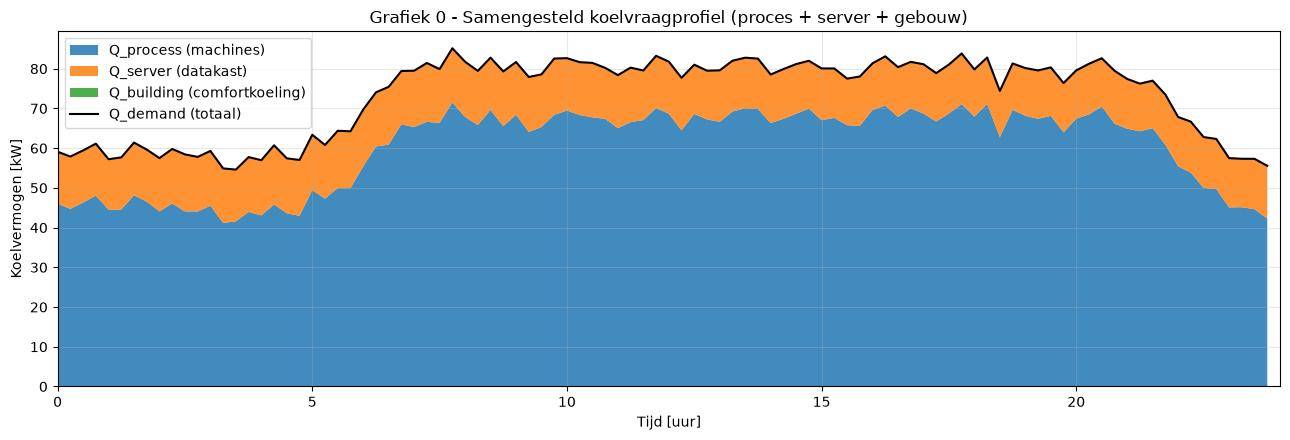

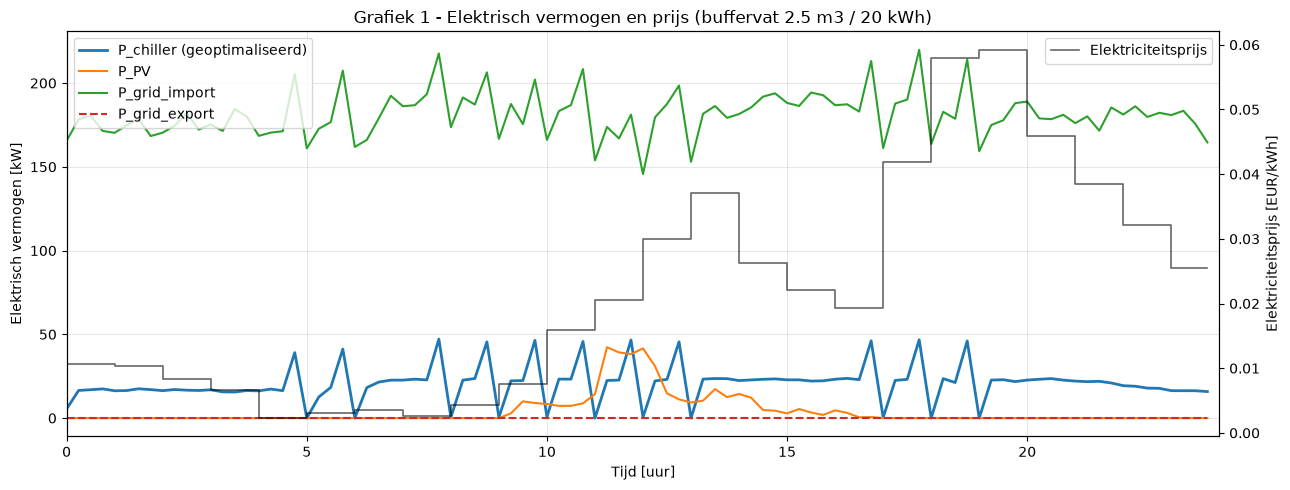

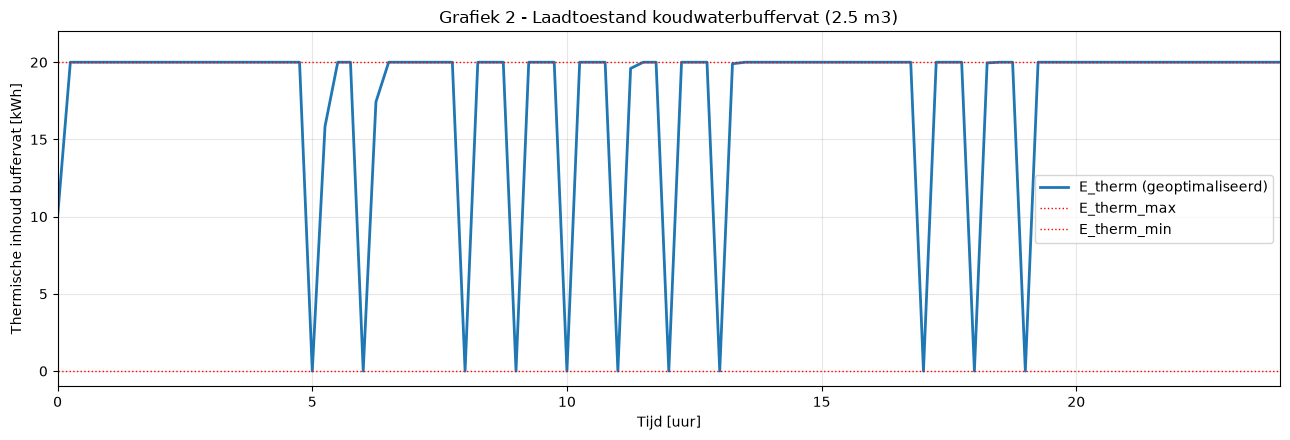

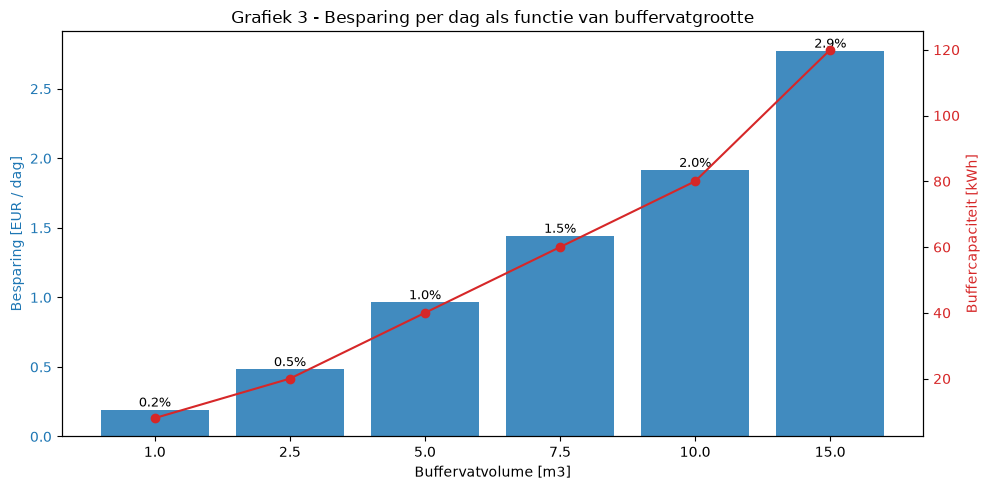


Grafieken opgeslagen:
  grafiek0_koelvraagprofiel.png
  grafiek1_vermogen_prijs.png
  grafiek2_buffervat.png
  grafiek3_besparing_vs_buffergrootte.png


In [8]:
"""
Optimalisatie van chiller-aansturing met koudwaterbuffervat (24 uur, kwartierresolutie)
=========================================================================================

Doel:
    Minimaliseer de netto elektriciteitskosten van een fabriek door het elektrisch
    vermogen van een chiller (met koudwaterbuffervat) slim te sturen, rekening
    houdend met de elektriciteitsprijs, PV-productie en niet-flexibele belasting.

Belangrijke aanpassing t.o.v. eerste versie:
    De kolom 'thermal_load' in plant1.csv is NIET de koelvraag van de machines alleen,
    maar een mix van proces-, gebouw-, servercooling en evt. verwarming. Omdat we hier
    specifiek een procesgekoelde chiller/buffervat willen modelleren, wordt een
    realistisch, zelfstandig koelvraagprofiel (Q_demand) opgebouwd uit fysisch
    onderbouwde componenten (zie sectie 2).

    Daarnaast wordt de buffervatgrootte gevarieerd over een reeks concrete,
    commercieel verkrijgbare tankvolumes (sectie 5), zodat je kan zien wat de
    impact van buffergrootte is op de haalbare besparing.

Auteur: Energiemanagement / CVXPY optimalisatie
"""

import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. DATA INLEZEN EN VOORBEREIDEN
# =============================================================================

CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

# Eerste 24 uur = eerste 96 kwartieren (96 * 15 min = 24 h)
N_STEPS = 96
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur, tijdstap

# Prijs staat in EUR/MWh in plant1.csv -> omrekenen naar EUR/kWh
price = df["price"].values / 1000.0            # [EUR/kWh]
P_pv = df["pv_production"].values               # [kW]
P_inflex = df["inflex_load"].values              # [kW]
T_outdoor = df["outdoor_temperature"].values     # [degC], gebruikt voor gebouwkoeling

time_h = np.arange(N_STEPS) * dt                # tijdas in uren (0 .. 23.75)

print(f"Data ingelezen: {N_STEPS} tijdstappen (24 uur, dt = {dt} h)")
print(f"Prijs range: {price.min():.4f} .. {price.max():.4f} EUR/kWh")
print(f"Buitentemperatuur range: {T_outdoor.min():.1f} .. {T_outdoor.max():.1f} degC")

# =============================================================================
# 2. REALISTISCH KOELVRAAGPROFIEL (Q_demand)
# =============================================================================
# In een echte fabriekssite bestaat de koelvraag op het buffervat doorgaans uit
# meerdere, onafhankelijke bijdragen. Hier construeren we een fysisch plausibel
# profiel opgebouwd uit drie componenten:
#
#   1) Q_process : procesgekoelde machines (bv. spuitgietmachines, compressoren,
#                  lasercutters, ...). Volgt het productieritme: hoger tijdens de
#                  dagploeg (06:00-22:00), lager 's nachts, met een vloeiende
#                  overgang bij ploegwissel en normale proces-ruis.
#   2) Q_server  : koeling van een serverruimte / datakast. Vrijwel constante
#                  24/7-belasting (IT-koeling stopt nooit), met kleine variatie.
#   3) Q_building: comfortkoeling van kantoren/gebouw. Enkel actief tijdens
#                  bezette uren (07:00-19:00) en enkel wanneer de buitentemperatuur
#                  boven een stookgrens ligt. Voor de winterdag in deze dataset
#                  (T_outdoor ~ 5-10 degC) is deze bijdrage nagenoeg nul, wat
#                  fysisch correct is: geen gebouwkoeling nodig bij koud weer.
#
# NB: eventuele verwarmingsvraag valt buiten de scope van dit chiller/koud-
# buffervatmodel (de chiller kan enkel koelen) en wordt hier niet meegenomen.

np.random.seed(42)  # reproduceerbare ruis

def shift_ramp(t_h, t_center, width=0.75):
    """Vloeiende (tanh) overgang rond ploegwissel-tijdstip t_center."""
    return 0.5 * (1 + np.tanh((t_h - t_center) / width))

# --- 1) Procesgekoelde machines ---
Q_process_night = 45.0    # kW, basislast nachtploeg / stand-by productie
Q_process_day = 68.0      # kW, volle dagproductie
ramp_up = shift_ramp(time_h, t_center=6.0)     # opstart dagploeg om 06:00
ramp_down = shift_ramp(time_h, t_center=22.0)  # afbouw naar nachtploeg om 22:00
Q_process = Q_process_night + (Q_process_day - Q_process_night) * (ramp_up * (1 - ramp_down))
Q_process += np.random.normal(0, 2.0, N_STEPS)  # normale procesruis
Q_process = np.clip(Q_process, 30, None)

# --- 2) Serverruimte / datakast ---
Q_server_base = 13.0       # kW, vrijwel constante IT-koellast
Q_server = Q_server_base + 1.0 * np.sin(2 * np.pi * time_h / 24.0) \
           + np.random.normal(0, 0.4, N_STEPS)
Q_server = np.clip(Q_server, 8, None)

# --- 3) Gebouw-/comfortkoeling ---
T_setpoint_cooling = 16.0   # degC, boven deze buitentemp. is er koelbehoefte
k_building = 2.2             # kW per graad boven setpoint
occupancy = np.where((time_h >= 7.0) & (time_h <= 19.0), 1.0, 0.15)
Q_building = k_building * np.clip(T_outdoor - T_setpoint_cooling, 0, None) * occupancy

# --- Totale koelvraag ---
Q_demand = Q_process + Q_server + Q_building
Q_demand = np.clip(Q_demand, 0, None)

print(f"\nSamengesteld koelvraagprofiel Q_demand:")
print(f"  Q_process  : {Q_process.min():5.1f} .. {Q_process.max():5.1f} kW")
print(f"  Q_server   : {Q_server.min():5.1f} .. {Q_server.max():5.1f} kW")
print(f"  Q_building : {Q_building.min():5.1f} .. {Q_building.max():5.1f} kW")
print(f"  Q_demand   : {Q_demand.min():5.1f} .. {Q_demand.max():5.1f} kW (totaal)")

# =============================================================================
# 3. VASTE PARAMETERS
# =============================================================================

# --- Chiller ---
P_max_chiller = 250.0      # kW elektrisch, maximaal vermogen chiller
EER_chiller = 3.5          # Energy Efficiency Ratio (voorlopig constant)

# --- Buffervat: thermofysische omrekening volume -> energie-inhoud ---
# E = m * cp * dT ,  m = rho * V
# rho_water = 1000 kg/m3, cp_water = 4.186 kJ/(kg.K)
# Bruikbaar temperatuurvenster: 6 degC - 12 degC  ->  dT = 6 K
# Dit geeft fysisch ~7.0 kWh/m3; we ronden naar een praktische 8.0 kWh/m3
# (marge voor menglagen/dode volumes), consistent met de referentiewaarde uit de
# opdracht (2.5 m3 -> 20 kWh).
RHO_WATER = 1000.0          # kg/m3
CP_WATER = 4.186            # kJ/(kg.K)
DELTA_T = 6.0                # K (12 degC - 6 degC)
KWH_PER_M3_PHYSICAL = RHO_WATER * CP_WATER * DELTA_T / 3600.0   # kJ -> kWh
KWH_PER_M3 = 8.0             # kWh/m3, praktische afgeronde waarde (zie opmerking hierboven)

print(f"\nFysische omrekening buffervat: {KWH_PER_M3_PHYSICAL:.2f} kWh/m3 (theoretisch)")
print(f"Gebruikte praktische omrekening: {KWH_PER_M3:.1f} kWh/m3")

eta_loss = 0.998            # stilstandsverlies-efficiëntie per tijdstap (~0.8%/uur)
E_therm_min = 0.0           # kWh, minimale thermische inhoud (ondergrens buffer)

# =============================================================================
# 4. OPTIMALISATIEFUNCTIE (herbruikbaar per buffergrootte)
# =============================================================================

def solve_chiller_schedule(E_therm_max, E_therm_0=None):
    """Lost het optimalisatieprobleem op voor een gegeven buffervatcapaciteit.

    Parameters
    ----------
    E_therm_max : float
        Maximale thermische inhoud van het buffervat [kWh].
    E_therm_0 : float, optional
        Startwaarde bij t=0 [kWh]. Standaard 50% van E_therm_max.

    Returns
    -------
    dict met opgeloste variabelen en de optimale kosten.
    """
    if E_therm_0 is None:
        E_therm_0 = 0.5 * E_therm_max

    P_chiller = cp.Variable(N_STEPS, nonneg=True)
    P_grid_import = cp.Variable(N_STEPS, nonneg=True)
    P_grid_export = cp.Variable(N_STEPS, nonneg=True)
    E_therm = cp.Variable(N_STEPS + 1)

    Q_chiller = EER_chiller * P_chiller

    constraints = [
        P_chiller <= P_max_chiller,
        E_therm[0] == E_therm_0,
        E_therm >= E_therm_min,
        E_therm <= E_therm_max,
        P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
    ]
    for t in range(N_STEPS):
        constraints += [
            E_therm[t + 1] == eta_loss * E_therm[t] + (-Q_chiller[t] + Q_demand[t]) * dt
        ]

    objective = cp.Minimize(
        cp.sum(cp.multiply(P_grid_import - P_grid_export, price) * dt)
    )
    problem = cp.Problem(objective, constraints)
    cost_opt = problem.solve(solver=cp.HIGHS)

    return {
        "status": problem.status,
        "cost": cost_opt,
        "E_therm_max": E_therm_max,
        "E_therm_0": E_therm_0,
        "P_chiller": P_chiller.value,
        "P_grid_import": P_grid_import.value,
        "P_grid_export": P_grid_export.value,
        "E_therm": E_therm.value,
    }

# =============================================================================
# 5. REFERENTIESCENARIO (chiller volgt Q_demand direct, geen sturing)
# =============================================================================
# Onafhankelijk van de buffergrootte: dit is het "business as usual"-scenario
# waarbij het buffervat niet actief wordt ingezet om te verschuiven in tijd.

P_chiller_ref = np.clip(Q_demand / EER_chiller, 0, P_max_chiller)
net_ref = P_chiller_ref + P_inflex - P_pv
P_grid_import_ref = np.clip(net_ref, 0, None)
P_grid_export_ref = np.clip(-net_ref, 0, None)
cost_ref = np.sum((P_grid_import_ref - P_grid_export_ref) * price * dt)

print(f"\nTotale kosten ZONDER optimalisatie (referentie): {cost_ref:.2f} EUR")

# =============================================================================
# 6. BUFFERVATGROOTTE LATEN VARIEREN (concrete, aankoopbare tankvolumes)
# =============================================================================
# Typische commercieel verkrijgbare (of eenvoudig te bestellen) tankvolumes
# voor een industrieel koudwaterbuffervat.

buffer_volumes_m3 = [1.0, 2.5, 5.0, 7.5, 10.0, 15.0]   # m3
buffer_results = []

for V in buffer_volumes_m3:
    E_max = V * KWH_PER_M3
    res = solve_chiller_schedule(E_therm_max=E_max)
    saving_eur = cost_ref - res["cost"]
    saving_pct = 100 * saving_eur / cost_ref if cost_ref != 0 else np.nan
    buffer_results.append({
        "volume_m3": V,
        "E_therm_max_kWh": E_max,
        "cost_opt": res["cost"],
        "saving_eur": saving_eur,
        "saving_pct": saving_pct,
        "solution": res,
    })
    print(f"  V = {V:5.1f} m3  ->  E_max = {E_max:5.1f} kWh  |  "
          f"kosten = {res['cost']:7.2f} EUR  |  besparing = {saving_eur:5.2f} EUR "
          f"({saving_pct:4.1f} %)  | status={res['status']}")

results_df = pd.DataFrame([
    {
        "Volume [m3]": r["volume_m3"],
        "E_therm_max [kWh]": r["E_therm_max_kWh"],
        "Kosten geoptimaliseerd [EUR]": r["cost_opt"],
        "Besparing [EUR]": r["saving_eur"],
        "Besparing [%]": r["saving_pct"],
    }
    for r in buffer_results
])

print("\n" + "=" * 70)
print("RESULTATENOVERZICHT PER BUFFERVATGROOTTE")
print("=" * 70)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:8.2f}"))
print("=" * 70)
print(f"Referentie (geen sturing) : {cost_ref:.2f} EUR")

# Representatieve case voor de gedetailleerde vermogens-/buffergrafieken:
# de oorspronkelijke ontwerpwaarde van 2.5 m3 (20 kWh).
representative = next(r for r in buffer_results if r["volume_m3"] == 2.5)
sol = representative["solution"]

# =============================================================================
# 7. GRAFIEKEN
# =============================================================================

# --- Grafiek 0: opbouw van het koelvraagprofiel ---
fig0, ax0 = plt.subplots(figsize=(13, 4.5))
ax0.stackplot(time_h, Q_process, Q_server, Q_building,
              labels=["Q_process (machines)", "Q_server (datakast)", "Q_building (comfortkoeling)"],
              colors=["tab:blue", "tab:orange", "tab:green"], alpha=0.85)
ax0.plot(time_h, Q_demand, color="black", linewidth=1.5, label="Q_demand (totaal)")
ax0.set_xlabel("Tijd [uur]")
ax0.set_ylabel("Koelvermogen [kW]")
ax0.set_xlim(0, 24)
ax0.set_title("Grafiek 0 - Samengesteld koelvraagprofiel (proces + server + gebouw)")
ax0.legend(loc="upper left")
ax0.grid(alpha=0.3)
fig0.tight_layout()
fig0.savefig("grafiek0_koelvraagprofiel.png", dpi=150)

# --- Grafiek 1: elektrisch vermogen + prijs (representatieve case: 2.5 m3) ---
fig1, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(time_h, sol["P_chiller"], label="P_chiller (geoptimaliseerd)", color="tab:blue", linewidth=2)
ax1.plot(time_h, P_pv, label="P_PV", color="tab:orange", linewidth=1.5)
ax1.plot(time_h, sol["P_grid_import"], label="P_grid_import", color="tab:green", linewidth=1.5)
ax1.plot(time_h, sol["P_grid_export"], label="P_grid_export", color="tab:red", linewidth=1.5, linestyle="--")
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, 24)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(time_h, price, where="post", color="black", linewidth=1.2, alpha=0.6, label="Elektriciteitsprijs")
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1b.legend(loc="upper right")
ax1.set_title(f"Grafiek 1 - Elektrisch vermogen en prijs (buffervat 2.5 m3 / {representative['E_therm_max_kWh']:.0f} kWh)")
fig1.tight_layout()
fig1.savefig("grafiek1_vermogen_prijs.png", dpi=150)

# --- Grafiek 2: laadtoestand buffervat (representatieve case: 2.5 m3) ---
fig2, ax2 = plt.subplots(figsize=(13, 4.5))
time_h_full = np.arange(N_STEPS + 1) * dt
ax2.plot(time_h_full, sol["E_therm"], label="E_therm (geoptimaliseerd)", color="tab:blue", linewidth=2)
ax2.axhline(representative["E_therm_max_kWh"], color="red", linestyle=":", linewidth=1, label="E_therm_max")
ax2.axhline(E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min")
ax2.set_xlabel("Tijd [uur]")
ax2.set_ylabel("Thermische inhoud buffervat [kWh]")
ax2.set_xlim(0, 24)
ax2.set_ylim(-1, representative["E_therm_max_kWh"] + 2)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_title("Grafiek 2 - Laadtoestand koudwaterbuffervat (2.5 m3)")
fig2.tight_layout()
fig2.savefig("grafiek2_buffervat.png", dpi=150)

# --- Grafiek 3: besparing als functie van buffervatgrootte ---
fig3, ax3 = plt.subplots(figsize=(10, 5))
volumes = [r["volume_m3"] for r in buffer_results]
savings_eur = [r["saving_eur"] for r in buffer_results]
savings_pct = [r["saving_pct"] for r in buffer_results]

bars = ax3.bar([str(v) for v in volumes], savings_eur, color="tab:blue", alpha=0.85)
ax3.set_xlabel("Buffervatvolume [m3]")
ax3.set_ylabel("Besparing [EUR / dag]", color="tab:blue")
ax3.tick_params(axis="y", labelcolor="tab:blue")
for bar, pct in zip(bars, savings_pct):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
              f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

ax3b = ax3.twinx()
E_max_list = [r["E_therm_max_kWh"] for r in buffer_results]
ax3b.plot([str(v) for v in volumes], E_max_list, color="tab:red", marker="o", label="E_therm_max [kWh]")
ax3b.set_ylabel("Buffercapaciteit [kWh]", color="tab:red")
ax3b.tick_params(axis="y", labelcolor="tab:red")

ax3.set_title("Grafiek 3 - Besparing per dag als functie van buffervatgrootte")
fig3.tight_layout()
fig3.savefig("grafiek3_besparing_vs_buffergrootte.png", dpi=150)

plt.show()

print("\nGrafieken opgeslagen:")
print("  grafiek0_koelvraagprofiel.png")
print("  grafiek1_vermogen_prijs.png")
print("  grafiek2_buffervat.png")
print("  grafiek3_besparing_vs_buffergrootte.png")

Data ingelezen: 96 tijdstappen (24 uur, dt = 0.25 h)
Prijs range: 0.0023 .. 0.0592 EUR/kWh
Buitentemperatuur range: 5.0 .. 9.7 degC

Samengesteld koelvraagprofiel Q_demand:
  Q_process  :  41.2 ..  71.5 kW
  Q_server   :  11.7 ..  14.9 kW
  Q_building :   0.0 ..   0.0 kW
  Q_demand   :  54.6 ..  85.2 kW (totaal)

Fysische omrekening buffervat: 6.98 kWh/m3 (theoretisch)
Gebruikte praktische omrekening: 8.0 kWh/m3

Totale kosten ZONDER optimalisatie (referentie): 96.69 EUR
  V =   1.0 m3  ->  E_max =   8.0 kWh  |  kosten =   96.54 EUR  |  besparing =  0.15 EUR ( 0.2 %)  | status=optimal
  V =   2.5 m3  ->  E_max =  20.0 kWh  |  kosten =   96.30 EUR  |  besparing =  0.39 EUR ( 0.4 %)  | status=optimal
  V =   5.0 m3  ->  E_max =  40.0 kWh  |  kosten =   95.92 EUR  |  besparing =  0.77 EUR ( 0.8 %)  | status=optimal
  V =   7.5 m3  ->  E_max =  60.0 kWh  |  kosten =   95.54 EUR  |  besparing =  1.15 EUR ( 1.2 %)  | status=optimal
  V =  10.0 m3  ->  E_max =  80.0 kWh  |  kosten =   95.16 E

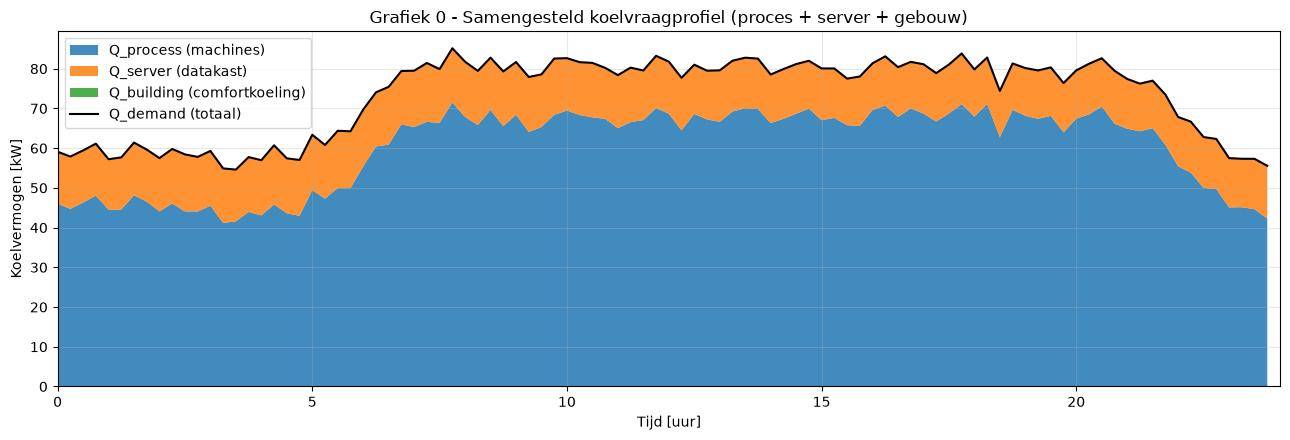

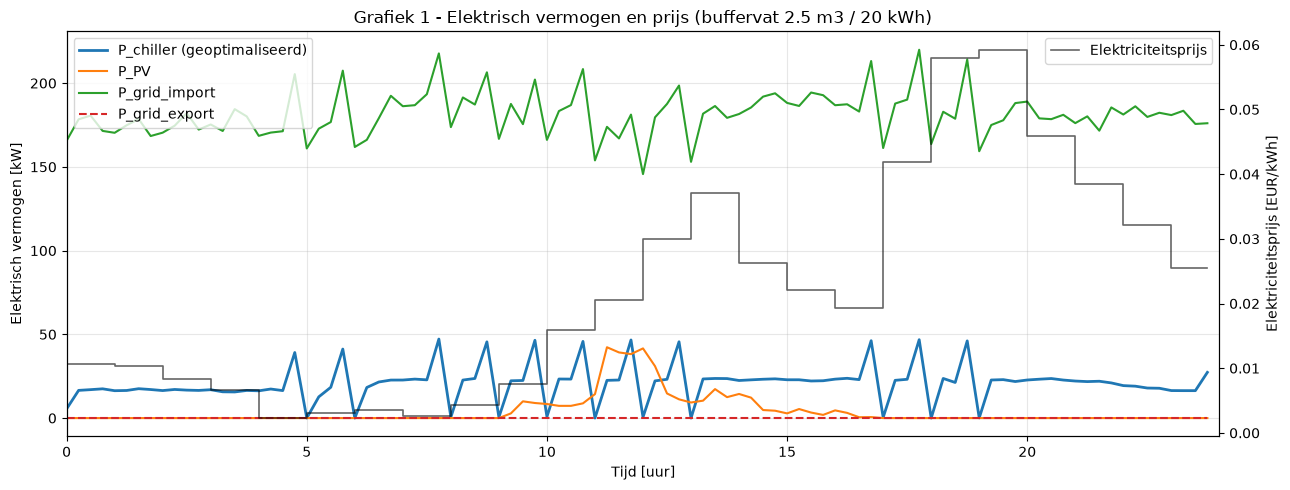

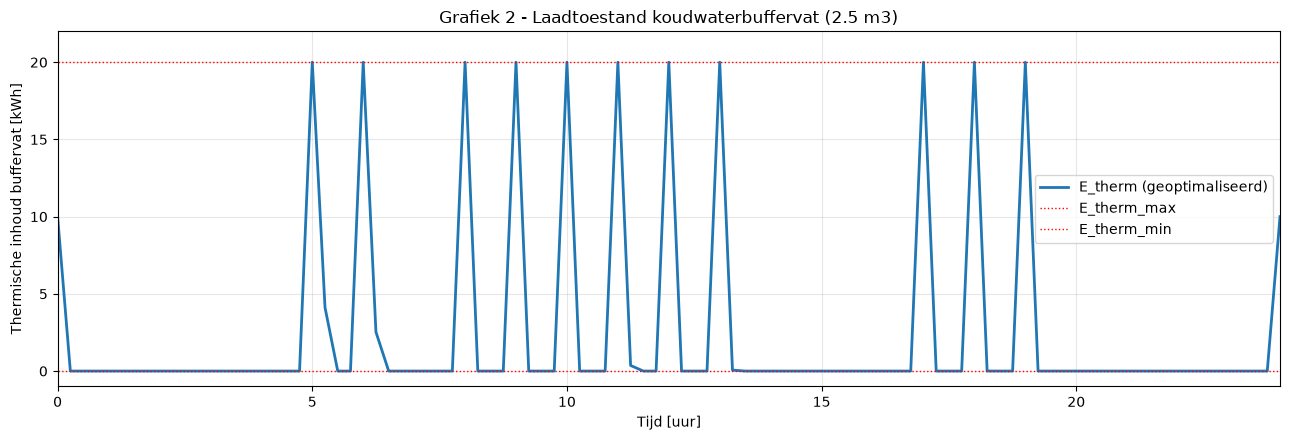

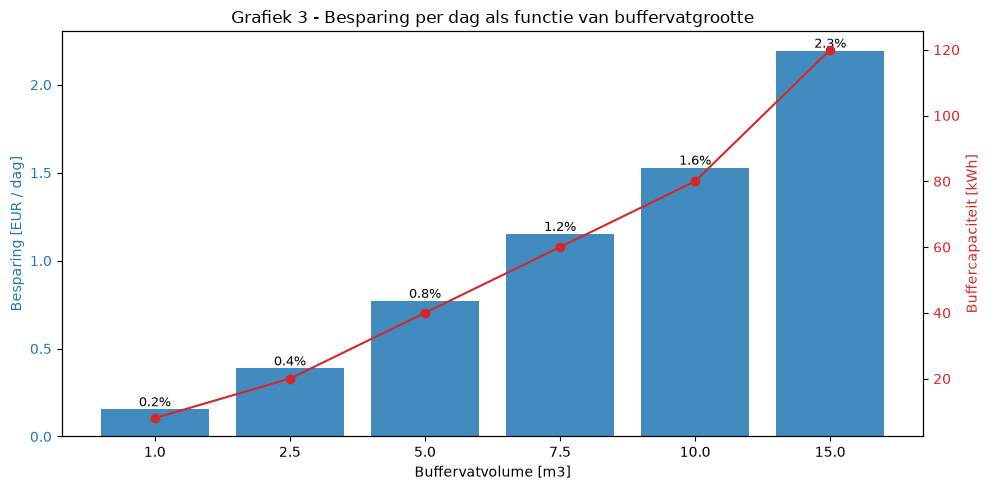


Grafieken opgeslagen:
  grafiek0_koelvraagprofiel.png
  grafiek1_vermogen_prijs.png
  grafiek2_buffervat.png
  grafiek3_besparing_vs_buffergrootte.png


In [9]:
"""
Optimalisatie van chiller-aansturing met koudwaterbuffervat (24 uur, kwartierresolutie)
=========================================================================================

Doel:
    Minimaliseer de netto elektriciteitskosten van een fabriek door het elektrisch
    vermogen van een chiller (met koudwaterbuffervat) slim te sturen, rekening
    houdend met de elektriciteitsprijs, PV-productie en niet-flexibele belasting.

Auteur: Energiemanagement / CVXPY optimalisatie
"""

import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. DATA INLEZEN EN VOORBEREIDEN
# =============================================================================

CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

# Eerste 24 uur = eerste 96 kwartieren (96 * 15 min = 24 h)
N_STEPS = 96
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur, tijdstap

# Prijs staat in EUR/MWh in plant1.csv -> omrekenen naar EUR/kWh
price = df["price"].values / 1000.0             # [EUR/kWh]
P_pv = df["pv_production"].values               # [kW]
P_inflex = df["inflex_load"].values              # [kW]
T_outdoor = df["outdoor_temperature"].values     # [degC], gebruikt voor gebouwkoeling

time_h = np.arange(N_STEPS) * dt                 # tijdas in uren (0 .. 23.75)

print(f"Data ingelezen: {N_STEPS} tijdstappen (24 uur, dt = {dt} h)")
print(f"Prijs range: {price.min():.4f} .. {price.max():.4f} EUR/kWh")
print(f"Buitentemperatuur range: {T_outdoor.min():.1f} .. {T_outdoor.max():.1f} degC")

# =============================================================================
# 2. REALISTISCH KOELVRAAGPROFIEL (Q_demand)
# =============================================================================

np.random.seed(42)  # reproduceerbare ruis

def shift_ramp(t_h, t_center, width=0.75):
    """Vloeiende (tanh) overgang rond ploegwissel-tijdstip t_center."""
    return 0.5 * (1 + np.tanh((t_h - t_center) / width))

# --- 1) Procesgekoelde machines ---
Q_process_night = 45.0    # kW, basislast nachtploeg / stand-by productie
Q_process_day = 68.0      # kW, volle dagproductie
ramp_up = shift_ramp(time_h, t_center=6.0)     # opstart dagploeg om 06:00
ramp_down = shift_ramp(time_h, t_center=22.0)  # afbouw naar nachtploeg om 22:00
Q_process = Q_process_night + (Q_process_day - Q_process_night) * (ramp_up * (1 - ramp_down))
Q_process += np.random.normal(0, 2.0, N_STEPS)  # normale procesruis
Q_process = np.clip(Q_process, 30, None)

# --- 2) Serverruimte / datakast ---
Q_server_base = 13.0       # kW, vrijwel constante IT-koellast
Q_server = Q_server_base + 1.0 * np.sin(2 * np.pi * time_h / 24.0) \
           + np.random.normal(0, 0.4, N_STEPS)
Q_server = np.clip(Q_server, 8, None)

# --- 3) Gebouw-/comfortkoeling ---
T_setpoint_cooling = 16.0   # degC, boven deze buitentemp. is er koelbehoefte
k_building = 2.2             # kW per graad boven setpoint
occupancy = np.where((time_h >= 7.0) & (time_h <= 19.0), 1.0, 0.15)
Q_building = k_building * np.clip(T_outdoor - T_setpoint_cooling, 0, None) * occupancy

# --- Totale koelvraag ---
Q_demand = Q_process + Q_server + Q_building
Q_demand = np.clip(Q_demand, 0, None)

print(f"\nSamengesteld koelvraagprofiel Q_demand:")
print(f"  Q_process  : {Q_process.min():5.1f} .. {Q_process.max():5.1f} kW")
print(f"  Q_server   : {Q_server.min():5.1f} .. {Q_server.max():5.1f} kW")
print(f"  Q_building : {Q_building.min():5.1f} .. {Q_building.max():5.1f} kW")
print(f"  Q_demand   : {Q_demand.min():5.1f} .. {Q_demand.max():5.1f} kW (totaal)")

# =============================================================================
# 3. VASTE PARAMETERS
# =============================================================================

# --- Chiller ---
P_max_chiller = 250.0      # kW elektrisch, maximaal vermogen chiller
EER_chiller = 3.5          # Energy Efficiency Ratio (constant)

# --- Buffervat: thermofysische omrekening volume -> energie-inhoud ---
RHO_WATER = 1000.0          # kg/m3
CP_WATER = 4.186            # kJ/(kg.K)
DELTA_T = 6.0                # K (12 degC - 6 degC)
KWH_PER_M3_PHYSICAL = RHO_WATER * CP_WATER * DELTA_T / 3600.0   # kJ -> kWh
KWH_PER_M3 = 8.0             # kWh/m3 (praktische afgeronde waarde)

print(f"\nFysische omrekening buffervat: {KWH_PER_M3_PHYSICAL:.2f} kWh/m3 (theoretisch)")
print(f"Gebruikte praktische omrekening: {KWH_PER_M3:.1f} kWh/m3")

eta_loss = 0.998            # stilstandsverlies-efficiëntie per tijdstap (~0.8%/uur)
E_therm_min = 0.0           # kWh, minimale thermische inhoud (ondergrens buffer)

# =============================================================================
# 4. OPTIMALISATIEFUNCTIE (herbruikbaar per buffergrootte)
# =============================================================================

def solve_chiller_schedule(E_therm_max, E_therm_0=None):
    """Lost het optimalisatieprobleem op voor een gegeven buffervatcapaciteit."""
    if E_therm_0 is None:
        E_therm_0 = 0.5 * E_therm_max

    P_chiller = cp.Variable(N_STEPS, nonneg=True)
    P_grid_import = cp.Variable(N_STEPS, nonneg=True)
    P_grid_export = cp.Variable(N_STEPS, nonneg=True)
    E_therm = cp.Variable(N_STEPS + 1)

    Q_chiller = EER_chiller * P_chiller

    constraints = [
        P_chiller <= P_max_chiller,
        E_therm[0] == E_therm_0,
        E_therm >= E_therm_min,
        E_therm <= E_therm_max,
        E_therm[N_STEPS] >= E_therm_0,  # <-- RANDVOORWAARDE EINDE DAG (voorkomt leegtrekken)
        P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
    ]
    for t in range(N_STEPS):
        constraints += [
            # <-- GECORRIGEERD: Chiller laadt op (+), koelvraag ontlaadt (-)
            E_therm[t + 1] == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
        ]

    objective = cp.Minimize(
        cp.sum(cp.multiply(P_grid_import - P_grid_export, price) * dt)
    )
    problem = cp.Problem(objective, constraints)
    cost_opt = problem.solve(solver=cp.HIGHS)

    return {
        "status": problem.status,
        "cost": cost_opt,
        "E_therm_max": E_therm_max,
        "E_therm_0": E_therm_0,
        "P_chiller": P_chiller.value,
        "P_grid_import": P_grid_import.value,
        "P_grid_export": P_grid_export.value,
        "E_therm": E_therm.value,
    }

# =============================================================================
# 5. REFERENTIESCENARIO (chiller volgt Q_demand direct, geen sturing)
# =============================================================================

P_chiller_ref = np.clip(Q_demand / EER_chiller, 0, P_max_chiller)
net_ref = P_chiller_ref + P_inflex - P_pv
P_grid_import_ref = np.clip(net_ref, 0, None)
P_grid_export_ref = np.clip(-net_ref, 0, None)
cost_ref = np.sum((P_grid_import_ref - P_grid_export_ref) * price * dt)

print(f"\nTotale kosten ZONDER optimalisatie (referentie): {cost_ref:.2f} EUR")

# =============================================================================
# 6. BUFFERVATGROOTTE LATEN VARIEREN
# =============================================================================

buffer_volumes_m3 = [1.0, 2.5, 5.0, 7.5, 10.0, 15.0]   # m3
buffer_results = []

for V in buffer_volumes_m3:
    E_max = V * KWH_PER_M3
    res = solve_chiller_schedule(E_therm_max=E_max)
    saving_eur = cost_ref - res["cost"]
    saving_pct = 100 * saving_eur / cost_ref if cost_ref != 0 else np.nan
    buffer_results.append({
        "volume_m3": V,
        "E_therm_max_kWh": E_max,
        "cost_opt": res["cost"],
        "saving_eur": saving_eur,
        "saving_pct": saving_pct,
        "solution": res,
    })
    print(f"  V = {V:5.1f} m3  ->  E_max = {E_max:5.1f} kWh  |  "
          f"kosten = {res['cost']:7.2f} EUR  |  besparing = {saving_eur:5.2f} EUR "
          f"({saving_pct:4.1f} %)  | status={res['status']}")

results_df = pd.DataFrame([
    {
        "Volume [m3]": r["volume_m3"],
        "E_therm_max [kWh]": r["E_therm_max_kWh"],
        "Kosten geoptimaliseerd [EUR]": r["cost_opt"],
        "Besparing [EUR]": r["saving_eur"],
        "Besparing [%]": r["saving_pct"],
    }
    for r in buffer_results
])

print("\n" + "=" * 70)
print("RESULTATENOVERZICHT PER BUFFERVATGROOTTE")
print("=" * 70)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:8.2f}"))
print("=" * 70)
print(f"Referentie (geen sturing) : {cost_ref:.2f} EUR")

representative = next(r for r in buffer_results if r["volume_m3"] == 2.5)
sol = representative["solution"]

# =============================================================================
# 7. GRAFIEKEN
# =============================================================================

# --- Grafiek 0: opbouw van het koelvraagprofiel ---
fig0, ax0 = plt.subplots(figsize=(13, 4.5))
ax0.stackplot(time_h, Q_process, Q_server, Q_building,
              labels=["Q_process (machines)", "Q_server (datakast)", "Q_building (comfortkoeling)"],
              colors=["tab:blue", "tab:orange", "tab:green"], alpha=0.85)
ax0.plot(time_h, Q_demand, color="black", linewidth=1.5, label="Q_demand (totaal)")
ax0.set_xlabel("Tijd [uur]")
ax0.set_ylabel("Koelvermogen [kW]")
ax0.set_xlim(0, 24)
ax0.set_title("Grafiek 0 - Samengesteld koelvraagprofiel (proces + server + gebouw)")
ax0.legend(loc="upper left")
ax0.grid(alpha=0.3)
fig0.tight_layout()
fig0.savefig("grafiek0_koelvraagprofiel.png", dpi=150)

# --- Grafiek 1: elektrisch vermogen + prijs (representatieve case: 2.5 m3) ---
fig1, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(time_h, sol["P_chiller"], label="P_chiller (geoptimaliseerd)", color="tab:blue", linewidth=2)
ax1.plot(time_h, P_pv, label="P_PV", color="tab:orange", linewidth=1.5)
ax1.plot(time_h, sol["P_grid_import"], label="P_grid_import", color="tab:green", linewidth=1.5)
ax1.plot(time_h, sol["P_grid_export"], label="P_grid_export", color="tab:red", linewidth=1.5, linestyle="--")
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, 24)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(time_h, price, where="post", color="black", linewidth=1.2, alpha=0.6, label="Elektriciteitsprijs")
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1b.legend(loc="upper right")
ax1.set_title(f"Grafiek 1 - Elektrisch vermogen en prijs (buffervat 2.5 m3 / {representative['E_therm_max_kWh']:.0f} kWh)")
fig1.tight_layout()
fig1.savefig("grafiek1_vermogen_prijs.png", dpi=150)

# --- Grafiek 2: laadtoestand buffervat (representatieve case: 2.5 m3) ---
fig2, ax2 = plt.subplots(figsize=(13, 4.5))
time_h_full = np.arange(N_STEPS + 1) * dt
ax2.plot(time_h_full, sol["E_therm"], label="E_therm (geoptimaliseerd)", color="tab:blue", linewidth=2)
ax2.axhline(representative["E_therm_max_kWh"], color="red", linestyle=":", linewidth=1, label="E_therm_max")
ax2.axhline(E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min")
ax2.set_xlabel("Tijd [uur]")
ax2.set_ylabel("Thermische inhoud buffervat [kWh]")
ax2.set_xlim(0, 24)
ax2.set_ylim(-1, representative["E_therm_max_kWh"] + 2)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_title("Grafiek 2 - Laadtoestand koudwaterbuffervat (2.5 m3)")
fig2.tight_layout()
fig2.savefig("grafiek2_buffervat.png", dpi=150)

# --- Grafiek 3: besparing als functie van buffervatgrootte ---
fig3, ax3 = plt.subplots(figsize=(10, 5))
volumes = [r["volume_m3"] for r in buffer_results]
savings_eur = [r["saving_eur"] for r in buffer_results]
savings_pct = [r["saving_pct"] for r in buffer_results]

bars = ax3.bar([str(v) for v in volumes], savings_eur, color="tab:blue", alpha=0.85)
ax3.set_xlabel("Buffervatvolume [m3]")
ax3.set_ylabel("Besparing [EUR / dag]", color="tab:blue")
ax3.tick_params(axis="y", labelcolor="tab:blue")
for bar, pct in zip(bars, savings_pct):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

ax3b = ax3.twinx()
E_max_list = [r["E_therm_max_kWh"] for r in buffer_results]
ax3b.plot([str(v) for v in volumes], E_max_list, color="tab:red", marker="o", label="E_therm_max [kWh]")
ax3b.set_ylabel("Buffercapaciteit [kWh]", color="tab:red")
ax3b.tick_params(axis="y", labelcolor="tab:red")

ax3.set_title("Grafiek 3 - Besparing per dag als functie van buffervatgrootte")
fig3.tight_layout()
fig3.savefig("grafiek3_besparing_vs_buffergrootte.png", dpi=150)

plt.show()

print("\nGrafieken opgeslagen:")
print("  grafiek0_koelvraagprofiel.png")
print("  grafiek1_vermogen_prijs.png")
print("  grafiek2_buffervat.png")
print("  grafiek3_besparing_vs_buffergrootte.png")

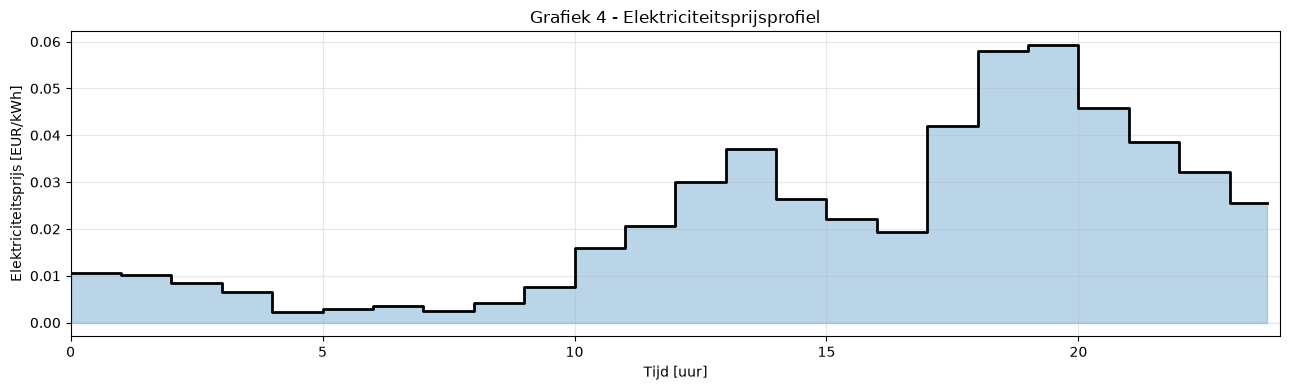

In [10]:
# --- Grafiek 4: Elektriciteitsprijs ---
fig4, ax4 = plt.subplots(figsize=(13, 4))
 
ax4.step(
time_h,
price,
where="post",
color="black",
linewidth=2
)
ax4.fill_between(
time_h,
price,
step="post",
alpha=0.3,
color="tab:blue"
)
ax4.set_xlabel("Tijd [uur]")
ax4.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax4.set_xlim(0, 24)
ax4.grid(alpha=0.3)


ax4.set_title("Grafiek 4 - Elektriciteitsprijsprofiel")


fig4.tight_layout()

fig4.savefig("grafiek4_prijsprofiel.png", dpi=150)


In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(time_h, Q_demand, label="Q_demand", linewidth=2)
ax.plot(time_h, sol["P_chiller"] * EER_chiller, label="Q_chiller", linewidth=2)

ax.set_xlabel("Tijd [uur]")
ax.set_ylabel("Koelvermogen [kW]")
ax.grid(alpha=0.3)
ax.legend()

plt.show()

SyntaxError: '[' was never closed (1772795441.py, line 4)